In [72]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [73]:
df = pd.read_csv('./data/DataPreprocessingGraded_dataset.csv')
df.head()
df.shape

,V1,V2,V3,V4,V5,Target
0,2.0,50.0,12500.0,98.0,NEGATIVE,YES
1,0.0,13.0,3250.0,28.0,NEGATIVE,YES
2,?,?,4000.0,35.0,NEGATIVE,YES
3,?,20.0,5000.0,45.0,NEGATIVE,YES
4,1.0,24.0,6000.0,77.0,NEGATIVE,NO


(748, 6)

## Convert question marks to proper null values

In [74]:
df = df.replace('?', np.nan)
df = df.astype({'V1': float, 'V2': float})
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 748 entries, 0 to 747
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   V1      743 non-null    float64
 1   V2      743 non-null    float64
 2   V3      748 non-null    float64
 3   V4      748 non-null    float64
 4   V5      748 non-null    str    
 5   Target  748 non-null    str    
dtypes: float64(4), str(2)
memory usage: 35.2 KB


In [75]:
df.describe()

,V1,V2,V3,V4
count,743.000000,743.000000,748.000000,748.000000
mean,9.562584,5.464334,1378.676471,34.282086
std,8.093527,5.799759,1459.826781,24.376714
min,0.000000,1.000000,250.000000,2.000000
25%,3.000000,2.000000,500.000000,16.000000
50%,8.000000,4.000000,1000.000000,28.000000
75%,14.000000,7.000000,1750.000000,50.000000
max,74.000000,50.000000,12500.000000,98.000000


In [76]:
df['V5'].value_counts()
df['Target'].value_counts()

V5
NEGATIVE    748
Name: count, dtype: int64

Target
NO     570
YES    178
Name: count, dtype: int64

## Outliers detection

In [77]:
numeric_cols = df.select_dtypes(include=[np.number]).columns
numeric_cols

Index(['V1', 'V2', 'V3', 'V4'], dtype='str')

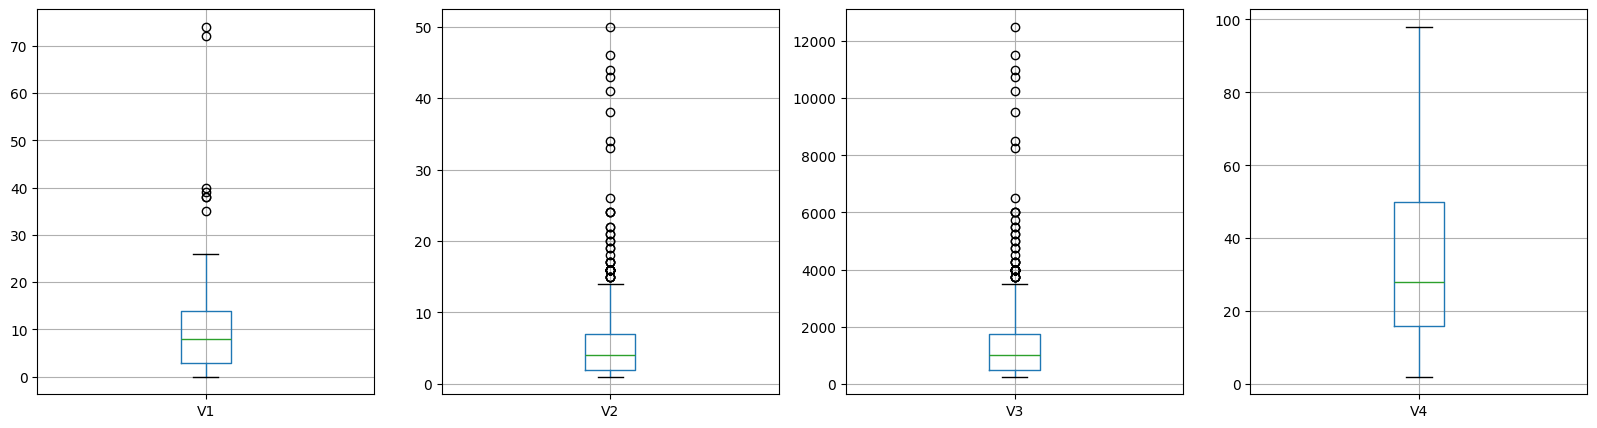

In [78]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for i, col in enumerate(numeric_cols):
  _ = df.boxplot(column=[col], ax=axes[i])
plt.show()

In [79]:
outlier_counts = pd.Series(dtype='int')

for col in numeric_cols:
  Q1 = df[col].quantile(0.25)
  Q3 = df[col].quantile(0.75)
  IQR = Q3 - Q1
  lower_bound = Q1 - 1.5 * IQR
  upper_bound = Q3 + 1.5 * IQR

  outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
  outlier_counts[col] = len(outliers)

outlier_counts

V1     7
V2    42
V3    45
V4     0
dtype: int64

## SimpleImputer

In [82]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='median')
imputer.fit_transform(df[numeric_cols])[:, 0].mean()

np.float64(9.552139037433156)

In [83]:
from sklearn.impute import KNNImputer

imputer = KNNImputer(n_neighbors=3)
imputer.fit_transform(df[numeric_cols])[:, 0].mean()

np.float64(9.532976827094473)

In [84]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='mean')
imputer.fit_transform(df[numeric_cols])[:, 1].mean()

np.float64(5.464333781965007)